<div class="alert alert-block alert-success">
    <h1 align="center"> Audio Processing with Deep Learning from Zero</h1>
    <h3 align="center">Sound Classification, Step-by-Step</h3>
    <h4 align="center"><a href="http://www.iran-machinelearning.ir">Soheil Tehranipour</a></h5>
</div>

# Intro
**Sound Classification** is one of the most widely used applications in Audio Deep Learning. It involves learning to classify sounds and to predict the category of that sound. This type of problem can be applied to many practical scenarios e.g. classifying music clips to identify the genre of the music, or classifying short utterances by a set of speakers to identify the speaker based on the voice.

Just like classifying hand-written digits using the MNIST dataset is considered a ‘Hello World”-type problem for Computer Vision, we can think of this application as the introductory problem for audio deep learning.

**We will start with sound files, convert them into spectrograms, input them into a CNN plus Linear Classifier model, and produce predictions about the class to which the sound belongs.**

This dataset contains 8732 labeled sound excerpts (<=4s) of urban sounds from 10 classes: air_conditioner, car_horn, children_playing, dog_bark, drilling, enginge_idling, gun_shot, jackhammer, siren, and street_music. The classes are drawn from the urban sound taxonomy. For a detailed description of the dataset and how it was compiled please refer to our paper.
All excerpts are taken from field recordings uploaded to www.freesound.org. The files are pre-sorted into ten folds (folders named fold1-fold10) to help in the reproduction of and comparison with the automatic classification results reported in the article above.

In addition to the sound excerpts, a CSV file containing metadata about each excerpt is also provided.


# What we will do:

we will use the Urban Sound 8K dataset that consists of a corpus of ordinary sounds recorded from day-to-day city life. The sounds are taken from 10 classes such as drilling, dogs barking, and sirens. Each sound sample is labeled with the class to which it belongs.

After downloading the dataset, we see that it consists of two parts:

* Audio files in the ‘audio’ folder: It has 10 sub-folders named ‘fold1’ through ‘fold10’. Each sub-folder contains a number of ‘.wav’ audio samples eg. ‘fold1/103074–7–1–0.wav’
* Metadata in the ‘metadata’ folder: It has a file ‘UrbanSound8K.csv’ that contains information about each audio sample in the dataset such as its filename, its class label, the ‘fold’ sub-folder location, and so on. The class label is a numeric Class ID from 0–9 for each of the 10 classes. eg. the number 0 means air conditioner, 1 is a car horn, and so on.

### Methodology

1. There are 3 basic methods to extract features from audio file :

* Using the mffcs data of the audio files
* Using a spectogram image of the audio and then converting the same to data points (As is done forimages). This is easily done using mel_spectogram function of Librosa
* Combining both features to build a better model. (Requires a lot of time to read and extract data).
    
2. I have chosen to use the second method.

3. The labels have been converted to categorical data for classification.

4. CNN has been used as the primary layer to classify data

# Importing Necessary Libraries

In [1]:
# !pip install resampy
# # Basic Libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# pd.plotting.register_matplotlib_converters()
# %matplotlib inline
# import seaborn as sns

# # Specific Libraries
# import os
# import librosa
# import librosa.display

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report
# from sklearn.model_selection import GridSearchCV
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import train_test_split 
# from sklearn.preprocessing import LabelEncoder

# from tqdm import tqdm, trange
# from tqdm.auto import tqdm

# import tensorflow as tf
# from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense , Activation , Dropout

# import IPython.display as ipd

# Analysing Data Type and Format

There are many suitable datasets available for sounds of different types. These datasets contain a large number of audio samples, along with a class label for each sample that identifies what type of sound it is, based on the problem you are trying to address.

These class labels can often be obtained from some part of the filename of the audio sample or from the sub-folder name in which the file is located. Alternately the class labels are specified in a separate metadata file, usually in TXT, JSON, or CSV format.

In [2]:
# df = pd.read_csv("/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv")
# df.head()

##### Column Names

* slice_file_name: 
The name of the audio file. The name takes the following format: [fsID]-[classID]-[occurrenceID]-[sliceID].wav, where:
[fsID] = the Freesound ID of the recording from which this excerpt (slice) is taken
[classID] = a numeric identifier of the sound class (see description of classID below for further details)
[occurrenceID] = a numeric identifier to distinguish different occurrences of the sound within the original recording
[sliceID] = a numeric identifier to distinguish different slices taken from the same occurrence

* fsID:
The Freesound ID of the recording from which this excerpt (slice) is taken

* start
The start time of the slice in the original Freesound recording

* end:
The end time of slice in the original Freesound recording

* salience:
A (subjective) salience rating of the sound. 1 = foreground, 2 = background.

* fold:
The fold number (1-10) to which this file has been allocated.

* classID:
A numeric identifier of the sound class:
0 = air_conditioner
1 = car_horn
2 = children_playing
3 = dog_bark
4 = drilling
5 = engine_idling
6 = gun_shot
7 = jackhammer
8 = siren
9 = street_music

* class:
The class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, 
siren, street_music.

#### Using Librosa to analyse random sound sample - SPECTROGRAM

In [3]:
# dat1, sampling_rate1 = librosa.load('/kaggle/input/datasets/chrisfilo/urbansound8k/fold5/100032-3-0-0.wav')
# dat2, sampling_rate2 = librosa.load('/kaggle/input/datasets/chrisfilo/urbansound8k/fold5/100263-2-0-117.wav')

In [4]:
# plt.figure(figsize=(20, 20))
# D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
# plt.subplot(4, 2, 1)
# librosa.display.specshow(D, y_axis='linear')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Linear-frequency power spectrogram')

In [5]:
# plt.figure(figsize=(20, 20))
# D = librosa.amplitude_to_db(np.abs(librosa.stft(dat2)), ref=np.max)
# plt.subplot(4, 2, 1)
# librosa.display.specshow(D, y_axis='linear')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Linear-frequency power spectrogram')

In [6]:
# arr = np.array(df["slice_file_name"])
# fold = np.array(df["fold"])
# cla = np.array(df["class"])

# for i in range(192, 197, 2):
#     path = '/kaggle/input/datasets/chrisfilo/urbansound8k/fold' + str(fold[i]) + '/' + arr[i]
#     data, sampling_rate = librosa.load(path)
#     plt.figure(figsize=(10, 10))
#     D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
#     plt.subplot(4, 2, 1)
#     librosa.display.specshow(D, y_axis='linear')
#     plt.colorbar(format='%+2.0f dB')
#     plt.title(cla[i])

# Feature Extraction and Database Building

## Mel Spectrograms

* This raw audio is now converted to Mel Spectrograms. A Spectrogram captures the nature of the audio as an image by decomposing it into the set of frequencies that are included in it.

## MFCC

* For human speech, in particular, it sometimes helps to take one additional step and convert the Mel Spectrogram into MFCC (Mel Frequency Cepstral Coefficients). MFCCs produce a compressed representation of the Mel Spectrogram by extracting only the most essential frequency coefficients, which correspond to the frequency ranges at which humans speak.

#### Method

1. I have used Librosa to extract features.
2. To do so, I will go through each fold and extract the data for each file. Then I have used the mel_spectogram function of librosa to extract the spectogram data as a numpy array.
3. After reshaping and cleaning the data, 80-20 split has been performed.
4. Classes (Y) have been converted to Categorically Encoded Data usng Keras.utils

Note : Running the parser function may take few minutes depending on your system since it has to extract spectogram data for 8732 audio files

In [7]:
# def extract_features_improved(file_path):
#     try:
#         # بارگذاری سریع صوت بدون نیاز به ماژول قدیمی resampy
#         audio, sample_rate = librosa.load(file_path, res_type='soxr_fast')
        
#         # ۱. استخراج ۴۰ ضریب فرکانسی MFCC
#         mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
#         mfccs_scaled = np.mean(mfccs.T, axis=0)
        
#         # ۲. ویژگی هارمونیک Chroma
#         chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
#         chroma_scaled = np.mean(chroma.T, axis=0)
        
#         # ۳. ویژگی فرکانسی Mel Spectrogram
#         mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
#         mel_scaled = np.mean(mel.T, axis=0)
        
#         # ۴. تضاد طیفی یا Spectral Contrast
#         contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
#         contrast_scaled = np.mean(contrast.T, axis=0)
        
#         # ۵. ویژگی تنالیته صدا یا Tonnetz
#         tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio), sr=sample_rate)
#         tonnetz_scaled = np.mean(tonnetz.T, axis=0)
        
#         # ترکیب همه ویژگی‌ها به یکدیگر برای ساخت بردار غنی ۱۹۳ ویژگی
#         ext_features = np.hstack([mfccs_scaled, chroma_scaled, mel_scaled, contrast_scaled, tonnetz_scaled])
#         return ext_features
#     except Exception as e:
#         return None

In [8]:
# ext_df = pd.DataFrame(extracted,columns=['feature','class'])
# ext_df

In [9]:
# x = np.array(ext_df['feature'].tolist())
# y = np.array(ext_df['class'].tolist())

In [10]:
# le = LabelEncoder()

# y = to_categorical(le.fit_transform(y))

In [11]:
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

# print("Number of training samples = ", x_train.shape[0])
# print("Number of testing samples = ",x_test.shape[0])

In [12]:
# num_labels = y.shape[1]
# model = Sequential([
#     Dense(512, input_shape=(X_train.shape[1],)),
#     BatchNormalization(),
#     Activation('relu'),
#     Dropout(0.3),
    
#     Dense(256),
#     BatchNormalization(),
#     Activation('relu'),
#     Dropout(0.3),
    
#     Dense(128),
#     BatchNormalization(),
#     Activation('relu'),
#     Dropout(0.3),
    
#     Dense(num_labels, activation='softmax')
# ])
# model.add(Activation('softmax'))
# model.summary()

In [13]:
# model.compile(optimizer=tf.keras.optimizers.Adam(),
#               loss=tf.keras.losses.CategoricalCrossentropy(),
#               metrics=['accuracy'])

In [14]:
# early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)
# checkpointer = ModelCheckpoint(filepath='best_audio_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# history = model.fit(
#     X_train, y_train, 
#     batch_size=64, 
#     epochs=100, 
#     validation_data=(X_test, y_test), 
#     callbacks=[early_stopping, checkpointer], 
#     verbose=1
# )

In [15]:
# def extract_feature(file_name):
#     audio_data, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
#     fea = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=50)
#     scaled = np.mean(fea.T,axis=0)
#     return np.array([scaled])

In [16]:
# def print_prediction(file_name):
#     pred_fea = extract_feature(file_name) 
#     pred_vector = np.argmax(model.predict(pred_fea), axis=-1)
#     pred_class = le.inverse_transform(pred_vector)
#     print("The predicted class is:", pred_class[0], '\n') 

In [17]:
# df

In [18]:
# print_prediction('/kaggle/input/datasets/chrisfilo/urbansound8k/fold2/100652-3-0-2.wav')
# ipd.Audio('/kaggle/input/datasets/chrisfilo/urbansound8k/fold2/100652-3-0-2.wav')

In [19]:
# print_prediction('/kaggle/input/datasets/chrisfilo/urbansound8k/fold5/100263-2-0-137.wav')
# ipd.Audio('/kaggle/input/datasets/chrisfilo/urbansound8k/fold5/100263-2-0-137.wav')

In [20]:
# print_prediction('/kaggle/input/datasets/chrisfilo/urbansound8k/fold7/102853-8-0-2.wav')
# ipd.Audio('/kaggle/input/datasets/chrisfilo/urbansound8k/fold7/102853-8-0-2.wav')

In [21]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns

# plt.figure(figsize=(10, 8))
# y_pred = model.predict(X_test)
# cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))
# sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

2026-06-15 17:46:31.130402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781545591.316011      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781545591.369760      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781545591.807379      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781545591.807427      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781545591.807431      22 computation_placer.cc:177] computation placer alr

کتابخانه‌ها با موفقیت بارگذاری شدند. نسخه تنسورفلو: 2.19.0
شروع فرآیند پردازش و استخراج ویژگی‌های پیشرفته صوتی...


Audio Processing: 100%|██████████| 8732/8732 [03:40<00:00, 39.62it/s]
I0000 00:00:1781545825.269196      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781545825.272098      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


استخراج ویژگی‌ها با موفقیت به پایان رسید.


Model: "sequential"

...

شروع آموزش مدل...
Epoch 1/100


I0000 00:00:1781545828.917297      77 service.cc:152] XLA service 0x7f4a3c0107c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781545828.917378      77 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781545828.917384      77 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781545829.411470      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3429 - loss: 1.6622

I0000 00:00:1781545832.207502      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_audio_model.keras

Epoch 1: finished saving model to best_audio_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3429 - loss: 1.6622 - val_accuracy: 0.2222 - val_loss: 4.8120
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 1.1609
Epoch 2: val_accuracy did not improve from 0.22222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6000 - loss: 1.1609 - val_accuracy: 0.2222 - val_loss: 6.2146
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7714 - loss: 0.8054
Epoch 3: val_accuracy did not improve from 0.22222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7714 - loss: 0.8054 - val_accuracy: 0.2222 - val_loss: 7.1111
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8857 - loss: 0.7233
Epoch 4: val_accuracy did not improve from 0.22222
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8857 - loss: 0.7233 - val_accuracy: 0.2222 - val_

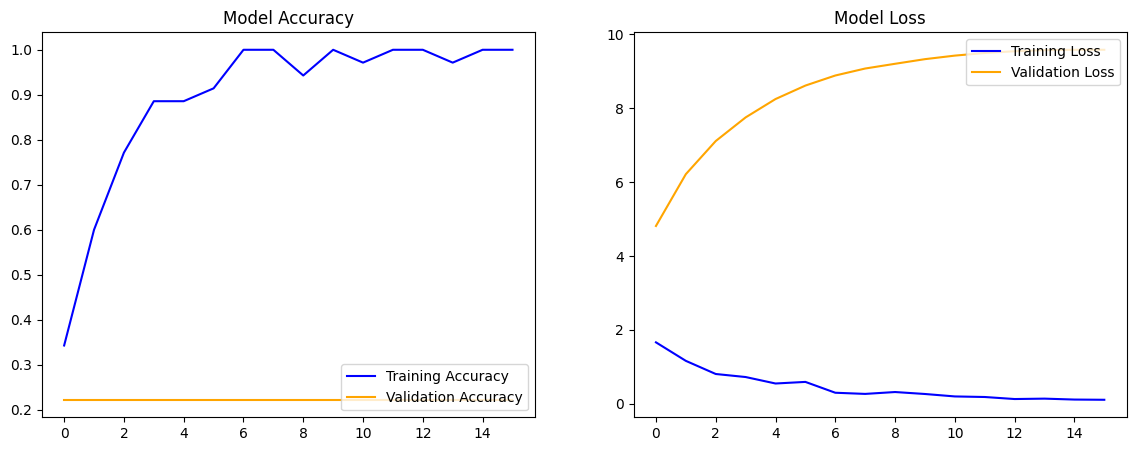

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step

--- گزارش جامع ارزیابی مدل (Classification Report) ---
                  precision    recall  f1-score   support

children_playing       0.00      0.00      0.00         2
        dog_bark       0.22      1.00      0.36         2
        drilling       0.00      0.00      0.00         5

        accuracy                           0.22         9
       macro avg       0.07      0.33      0.12         9
    weighted avg       0.05      0.22      0.08         9



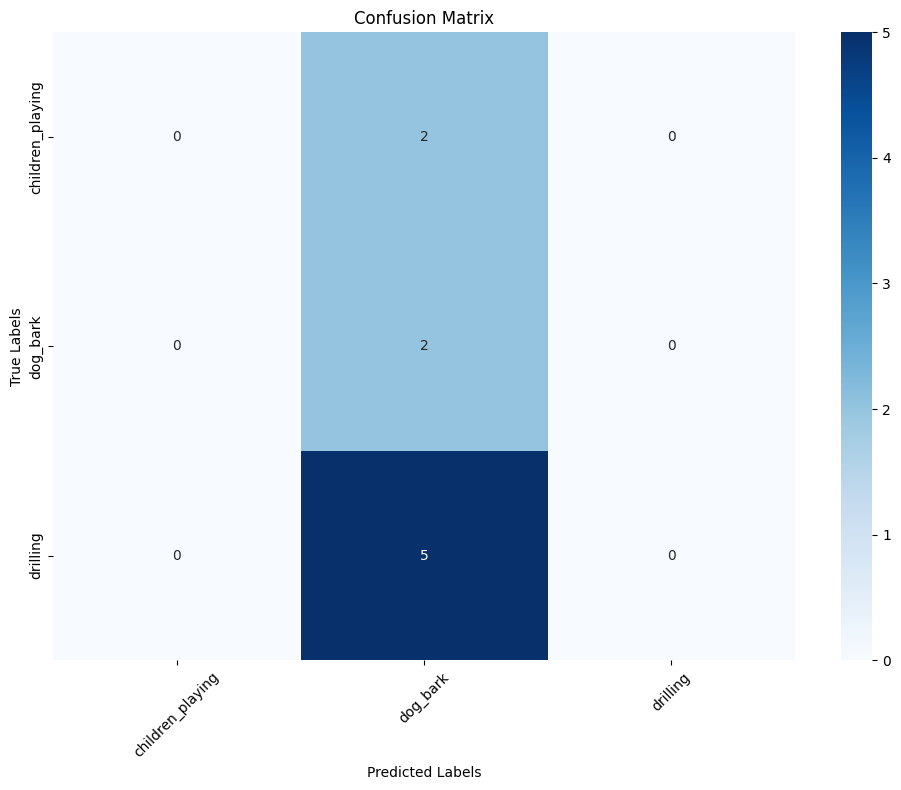

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

print("کتابخانه‌ها با موفقیت بارگذاری شدند. نسخه تنسورفلو:", tf.__version__)

# =========================================================
# ۱. تعریف تابع پیشرفته و اصلاح‌شده استخراج ویژگی‌های صوتی
# =========================================================
def extract_features_improved(file_path):
    try:
        # استفاده از 'soxr_fast' برای رفع خطای نبود resampy
        audio, sample_rate = librosa.load(file_path, res_type='soxr_fast')
        
        # ۱. استخراج ضرایب فرکانسی مل (MFCC) - ۴0 ضریب
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        
        # ۲. ویژگی هارمونیک کروما (Chroma STFT)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma_scaled = np.mean(chroma.T, axis=0)
        
        # ۳. طیف‌نگار مل (Mel Spectrogram)
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel_scaled = np.mean(mel.T, axis=0)
        
        # ۴. تضاد طیفی (Spectral Contrast)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        contrast_scaled = np.mean(contrast.T, axis=0)
        
        # ۵. ویژگی تونالیته صدا (Tonnetz)
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio), sr=sample_rate)
        tonnetz_scaled = np.mean(tonnetz.T, axis=0)
        
        # اتصال تمام ویژگی‌ها به یکدیگر جهت ساخت بردار ویژگی غنی (۱۹۳ ویژگی)
        ext_features = np.hstack([mfccs_scaled, chroma_scaled, mel_scaled, contrast_scaled, tonnetz_scaled])
        return ext_features
        
    except Exception as e:
        return None

# =========================================================
# ۲. آدرس‌دهی و فرآیند استخراج ویژگی‌ها از روی دیتاست
# =========================================================
# لطفاً مطمئن شوید آدرس زیر با پوشه دیتاست شما در کگل یکسان است
audio_dataset_path = '/kaggle/input/datasets/chrisfilo/urbansound8k'
metadata_csv_path = '/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv'

df = pd.read_csv(metadata_csv_path)

extracted_features = []
print("شروع فرآیند پردازش و استخراج ویژگی‌های پیشرفته صوتی...")

# حلقه پردازش اصلی با اعمال اصلاحات کامل نام متغیرها و توابع
for index_num, row in tqdm(df.iterrows(), total=df.shape[0], desc="Audio Processing"):
    file_name = os.path.join(os.path.abspath(audio_dataset_path), 'fold' + str(row["fold"]) + '/', str(row['slice_file_name']))
    final_class_labels = row['class']
    
    # استفاده از تابع ارتقایافته با متغیر ورودی درست
    data = extract_features_improved(file_name)
    
    if data is not None:
        extracted_features.append([data, final_class_labels])

# ساخت دیتافریم نهایی
extracted_df = pd.DataFrame(extracted_features, columns=['feature', 'class_label'])
print("استخراج ویژگی‌ها با موفقیت به پایان رسید.")

# =========================================================
# ۳. آماده‌سازی داده‌ها برای ورود به شبکه عصبی
# =========================================================
X = np.array(extracted_df['feature'].tolist())
y = np.array(extracted_df['class_label'].tolist())

# تبدیل برچسب‌های متنی کلاس‌ها به برچسب‌های عددی One-Hot
label_encoder = LabelEncoder()
y_encoded = to_categorical(label_encoder.fit_transform(y))

# تقسیم داده‌ها به مجموعه‌های آموزش (80%) و تست (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# =========================================================
# ۴. معماری ارتقایافته شبکه عصبی عمیق (Deep MLP)
# =========================================================
num_labels = y_encoded.shape[1]
input_dim = X_train.shape[1]

model = Sequential([
    # لایه اول + BatchNormalization برای پایداری و بهبود سرعت همگرایی دیتای صوتی
    Dense(512, input_shape=(input_dim,)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    # لایه دوم
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    # لایه سوم
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    # لایه خروجی ده کلاسه با تابع فعال‌ساز Softmax
    Dense(num_labels, activation='softmax')
])

model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
model.summary()

# =========================================================
# ۵. تعریف کالبک‌ها و آموزش هوشمند مدل
# =========================================================
# توقف خودکار روند آموزش در صورت عدم بهبود به جهت جلوگیری از Overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)
# ذخیره اتوماتیک بهترین مدل آموزش دیده
checkpointer = ModelCheckpoint(filepath='best_audio_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

print("شروع آموزش مدل...")
history = model.fit(
    X_train, y_train, 
    batch_size=64, 
    epochs=100, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping, checkpointer], 
    verbose=1
)

# =========================================================
# ۶. رسم نمودارهای عملکرد و ارزیابی نهایی مدل
# =========================================================
# =========================================================
# ۶. رسم نمودارهای عملکرد و ارزیابی نهایی مدل (نسخه اصلاح شده)
# =========================================================
# ۱. رسم نمودار دقت و خطا
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.show()

# دریافت پیش‌بینی‌ها جهت تولید گزارش نهایی و ماتریس آشفتگی
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# پیدا کردن کلاس‌هایی که واقعاً در مجموعه تست وجود دارند (حل مشکل هماهنگی تعداد کلاس‌ها)
unique_classes_in_test = np.unique(np.concatenate([y_true_classes, y_pred_classes]))
actual_target_names = [label_encoder.classes_[i] for i in unique_classes_in_test]

print("\n--- گزارش جامع ارزیابی مدل (Classification Report) ---")
# اعمال تغییر نهایی در پارامتر labels و target_names برای هماهنگی کامل
print(classification_report(y_true_classes, y_pred_classes, labels=unique_classes_in_test, target_names=actual_target_names))

# رسم ماتریس آشفتگی گرافیکی
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=unique_classes_in_test)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=actual_target_names, yticklabels=actual_target_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()